# GNN model evaluation

This notebook evaluates the models trained by `scripts/21_train_static_gnns.py` and `scripts/22_train_temporal_gnn.py`.

It examines:

1. validation performance across the complete modeling ladder;
2. training and validation errors for static GraphSAGE and GAT;
3. held-out performance of the validation-selected models;
4. prediction similarity and Fragility Score ordering; and
5. comparable residual diagnostics.

The notebook reads frozen model outputs only. It does not retrain or reselect any model.

## 1. Setup and model outputs

In [1]:
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

project_root = Path.cwd().resolve()
while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise RuntimeError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    TWO_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()
results_directory = paths.tables / "modeling"
files = {
    "baseline validation": results_directory / "baseline_validation_performance.csv",
    "network validation": results_directory / "network_validation_performance.csv",
    "GNN validation": results_directory / "gnn_validation_performance.csv",
    "static GNN history": results_directory / "static_gnn_training_history.csv",
    "predictive benchmarks": results_directory / "predictive_benchmark_performance.csv",
    "baseline test": results_directory / "selected_baseline_test_performance.csv",
    "network test": results_directory / "selected_network_test_performance.csv",
    "GNN test": results_directory / "selected_gnn_test_performance.csv",
    "baseline predictions": results_directory / "selected_baseline_test_predictions.parquet",
    "network predictions": results_directory / "selected_network_test_predictions.parquet",
    "GNN predictions": results_directory / "selected_gnn_test_predictions.parquet",
}
for description, path in files.items():
    if not path.is_file():
        raise FileNotFoundError(f"{description} not found: {path}")

baseline_validation = pd.read_csv(files["baseline validation"])
network_validation = pd.read_csv(files["network validation"])
gnn_validation = pd.read_csv(files["GNN validation"])
static_history = pd.read_csv(files["static GNN history"])
benchmarks = pd.read_csv(files["predictive benchmarks"])
baseline_test = pd.read_csv(files["baseline test"])
network_test = pd.read_csv(files["network test"])
gnn_test = pd.read_csv(files["GNN test"])
test_benchmark = benchmarks.loc[benchmarks["sample_split"].eq("test")].copy()
if len(test_benchmark) != 1 or test_benchmark["model"].item() != "naive_mean":
    raise RuntimeError("The test benchmark is missing or invalid.")

keys = ["report_period", "information_date", "permno"]
target = "future_max_drawdown_63d"
prediction = "predicted_future_max_drawdown_63d"
prediction_files = {
    "Baseline": files["baseline predictions"],
    "Engineered network": files["network predictions"],
    "GNN": files["GNN predictions"],
}
panels = {}
for name, path in prediction_files.items():
    prefix = name.lower().replace(" ", "_")
    panels[name] = pd.read_parquet(path).rename(
        columns={
            target: f"{prefix}_actual",
            prediction: f"{prefix}_prediction",
            "fragility_score": f"{prefix}_score",
        }
    )

panel = panels["Baseline"]
for name in ["Engineered network", "GNN"]:
    panel = panel.merge(panels[name], on=keys, how="inner", validate="one_to_one")
if any(len(frame) != len(panel) for frame in panels.values()):
    raise RuntimeError("The selected models do not cover identical test observations.")
if not np.allclose(panel["baseline_actual"], panel["engineered_network_actual"]) or not np.allclose(panel["baseline_actual"], panel["gnn_actual"]):
    raise RuntimeError("The test targets differ across prediction files.")
panel = panel.rename(columns={"baseline_actual": "actual"}).drop(columns=["engineered_network_actual", "gnn_actual"])

print(f"Selected primary model: {baseline_test.loc[0, 'model']}")
print(f"Selected engineered-network model: {network_test.loc[0, 'model']}")
print(f"Selected GNN: {gnn_test.loc[0, 'model']}")
print(f"Common held-out observations: {len(panel):,}")

Selected primary model: xgboost_augmented
Selected engineered-network model: xgboost_network
Selected GNN: temporal_graphsage
Common held-out observations: 30,511


## 2. Validation model ladder

All architecture choices were made using validation MAE. Lower values are better. Test results played no role in selecting the temporal GNN or any earlier model.

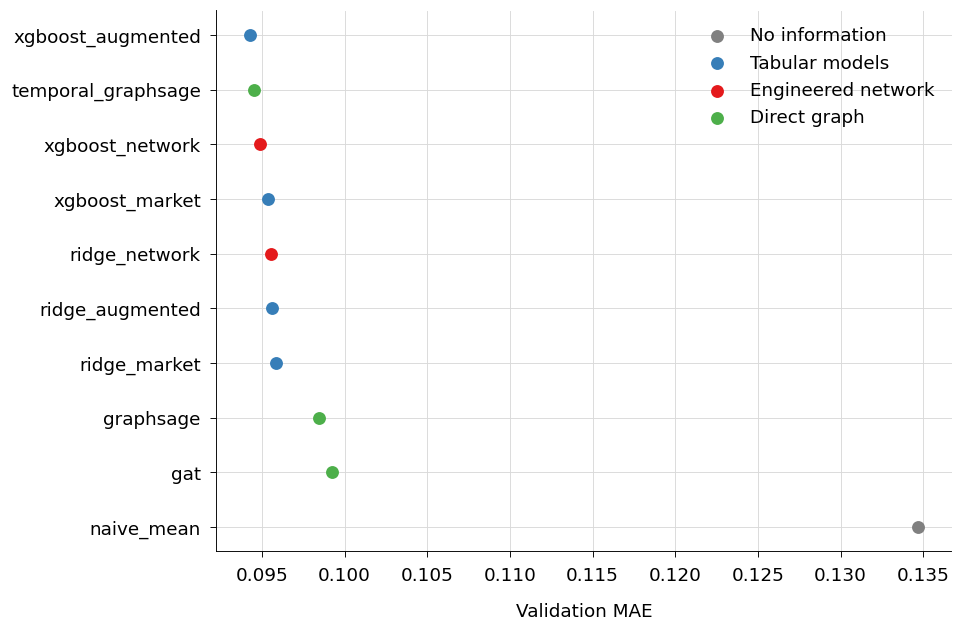

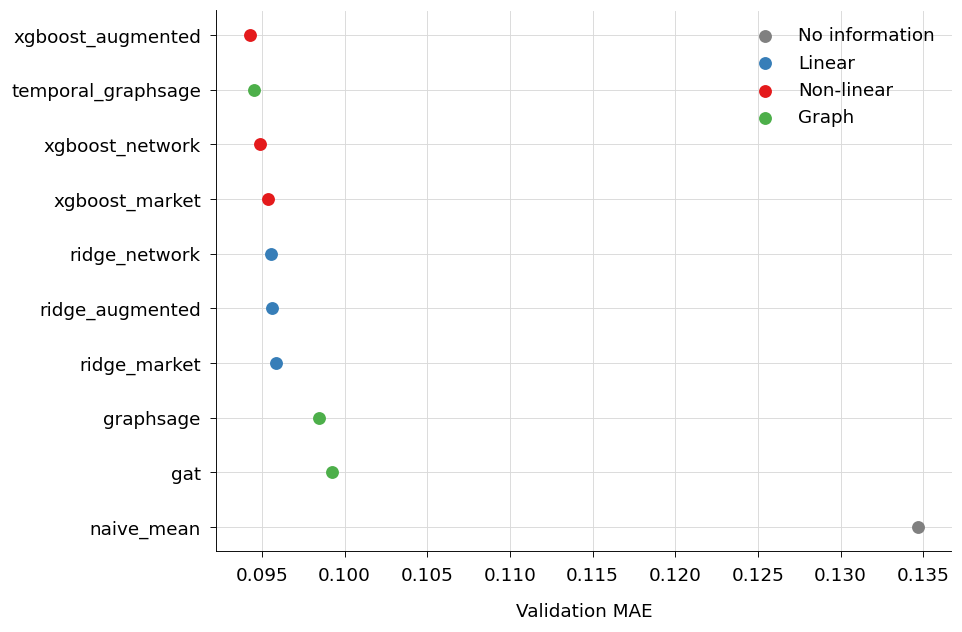

In [2]:
baseline_ladder = baseline_validation.copy()
baseline_ladder["family"] = "Tabular models"
baseline_ladder.loc[
    baseline_ladder["model"].eq("naive_mean"),
    "family",
] = "No information"

network_ladder = network_validation.copy()
network_ladder["family"] = "Engineered network"

gnn_ladder = gnn_validation.copy()
gnn_ladder["family"] = "Direct graph"

validation_ladder = pd.concat(
    [baseline_ladder, network_ladder, gnn_ladder],
    ignore_index=True,
).sort_values("mae").reset_index(drop=True)

feature_group_colors = {
    "No information": "gray",
    "Tabular models": COLOR_PALETTE[0],
    "Engineered network": COLOR_PALETTE[1],
    "Direct graph": COLOR_PALETTE[2],
}

fig, ax = plt.subplots(figsize=(9, 6))

for group, color in feature_group_colors.items():
    rows = validation_ladder["family"].eq(group)

    ax.scatter(
        validation_ladder.loc[rows, "mae"],
        validation_ladder.index[rows],
        color=color,
        s=55,
        label=group,
    )

ax.set_yticks(
    validation_ladder.index,
    validation_ladder["model"],
)

ax.invert_yaxis()
ax.set_xlabel("Validation MAE")
ax.set_ylabel("")
ax.legend(frameon=False)

apply_matplotlib_layout(fig)

fig.savefig(
    paths.figures / "04_06_validation_ladder_feature_group.pdf"
)

plt.show()

validation_ladder["model_family"] = "Non-linear"

validation_ladder.loc[
    validation_ladder["model"].str.contains(
        "linear|ridge|lasso",
        case=False,
        regex=True,
    ),
    "model_family",
] = "Linear"

validation_ladder.loc[
    validation_ladder["family"].eq("Direct graph"),
    "model_family",
] = "Graph"

validation_ladder.loc[
    validation_ladder["model"].eq("naive_mean"),
    "model_family",
] = "No information"


model_family_colors = {
    "No information": "gray",
    "Linear": COLOR_PALETTE[0],
    "Non-linear": COLOR_PALETTE[1],
    "Graph": COLOR_PALETTE[2],
}

fig, ax = plt.subplots(figsize=(9, 6))

for group, color in model_family_colors.items():
    rows = validation_ladder["model_family"].eq(group)

    ax.scatter(
        validation_ladder.loc[rows, "mae"],
        validation_ladder.index[rows],
        color=color,
        s=55,
        label=group,
    )

ax.set_yticks(
    validation_ladder.index,
    validation_ladder["model"],
)

ax.invert_yaxis()
ax.set_xlabel("Validation MAE")
ax.set_ylabel("")
ax.legend(frameon=False)

apply_matplotlib_layout(fig)

fig.savefig(
    paths.figures / "04_06_validation_ladder_model_family.pdf"
)

plt.show()

## 3. Static GNN learning curves

Training loss and validation MAE are recorded after every epoch for GraphSAGE and GAT. Each training epoch processes the quarterly training graphs one at a time; validation is evaluated only after the complete epoch, so an epoch—not an individual graph batch—is the correct common horizontal unit. The dotted line marks the validation-selected epoch.

,final_epoch,minimum_validation_mae
model,,
GraphSAGE,28,0.098452
GAT,31,0.099248


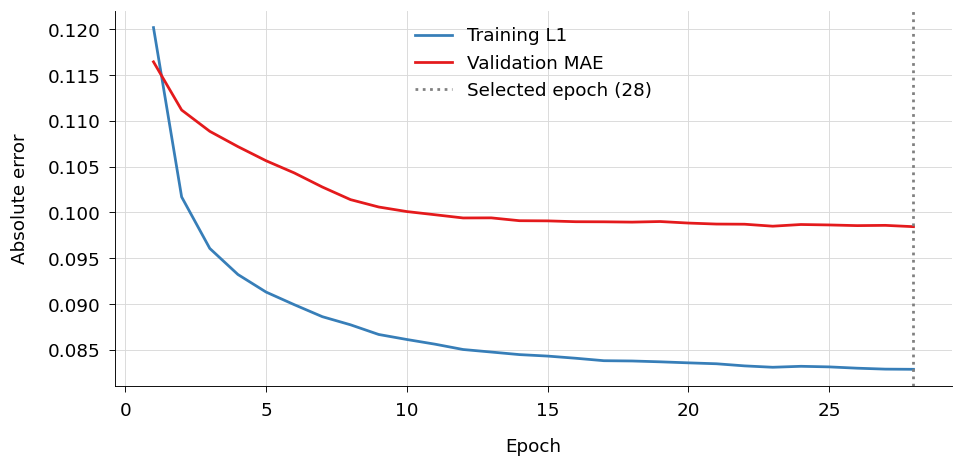

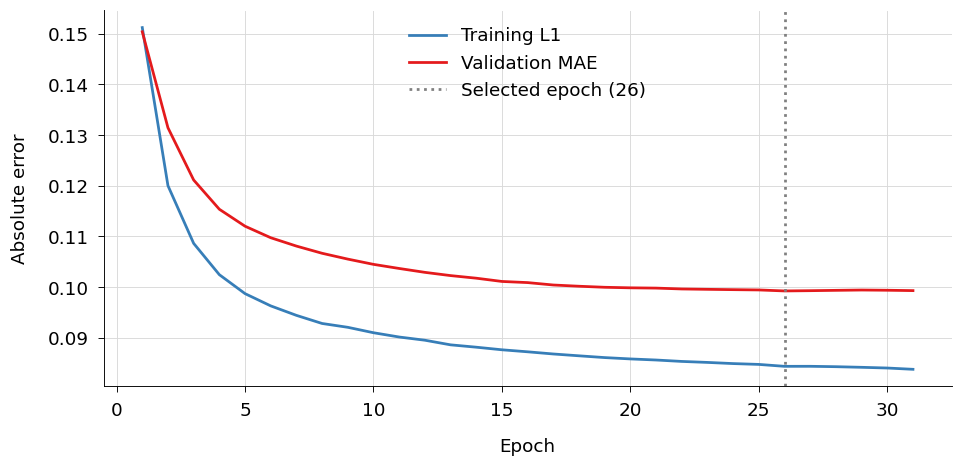

In [3]:
model_labels = {"graphsage": "GraphSAGE", "gat": "GAT"}
best_epochs = gnn_validation.set_index("model")["best_epoch"].to_dict()

history_summary = (
    static_history.groupby("model", sort=False)
    .agg(
        final_epoch=("epoch", "max"),
        minimum_validation_mae=("validation_mae", "min"),
    )
    .rename(index=model_labels)
)
display(history_summary.style.format({"minimum_validation_mae": "{:.6f}"}))

for model in ["graphsage", "gat"]:
    rows = static_history.loc[static_history["model"].eq(model)]
    fig, ax = plt.subplots(figsize=SINGLE_PANEL_SIZE)
    ax.plot(
        rows["epoch"],
        rows["training_l1"],
        color=COLOR_PALETTE[0],
        label="Training L1",
    )
    ax.plot(
        rows["epoch"],
        rows["validation_mae"],
        color=COLOR_PALETTE[1],
        label="Validation MAE",
    )
    ax.axvline(
        best_epochs[model],
        color="gray",
        linestyle=":",
        label=f"Selected epoch ({best_epochs[model]})",
    )
    ax.set_ylabel("Absolute error")
    ax.set_xlabel("Epoch")
    ax.legend()
    apply_matplotlib_layout(fig)
    fig.savefig(paths.figures / f"04_06_{model}_learning_curve.pdf")
    plt.show()

## 4. Held-out test comparison

Only the previously selected model from each stage appears here. The GNN family had already been reduced to temporal GraphSAGE before its test results were calculated. The historical-mean forecast is included as the common no-information benchmark.

In [4]:
test_comparison = pd.concat(
    [
        test_benchmark.assign(stage="No information", mean_quarterly_spearman=np.nan),
        baseline_test.assign(stage="Primary XGBoost"),
        network_test.assign(stage="Engineered network"),
        gnn_test.assign(stage="Direct graph"),
    ],
    ignore_index=True,
)
display(
    test_comparison[["stage", "model", "observations", "quarters", "mae", "rmse", "r2", "mean_quarterly_spearman"]]
    .style.format({"mae": "{:.6f}", "rmse": "{:.6f}", "r2": "{:.4f}", "mean_quarterly_spearman": "{:.4f}"})
)

baseline_mae = baseline_test.loc[0, "mae"]
network_mae = network_test.loc[0, "mae"]
gnn_mae = gnn_test.loc[0, "mae"]
print(f"GNN versus primary XGBoost MAE: {gnn_mae - baseline_mae:+.6f} ({gnn_mae / baseline_mae - 1:+.2%})")
print(f"GNN versus engineered-network MAE: {gnn_mae - network_mae:+.6f} ({gnn_mae / network_mae - 1:+.2%})")

,stage,model,observations,quarters,mae,rmse,r2,mean_quarterly_spearman
0,No information,naive_mean,30511,8,0.130198,0.181926,-0.0528,nan
1,Primary XGBoost,xgboost_augmented,30511,8,0.090403,0.124903,0.5038,0.7390
2,Engineered network,xgboost_network,30511,8,0.089988,0.124527,0.5068,0.7381
3,Direct graph,temporal_graphsage,30511,8,0.089762,0.126264,0.4929,0.7394


GNN versus primary XGBoost MAE: -0.000641 (-0.71%)
GNN versus engineered-network MAE: -0.000226 (-0.25%)


## 5. Test performance by quarter

Quarter-level MAE and rank correlation show whether aggregate differences are stable through time. The horizontal references show aggregate naive-mean error and the zero correlation expected from random ordering.

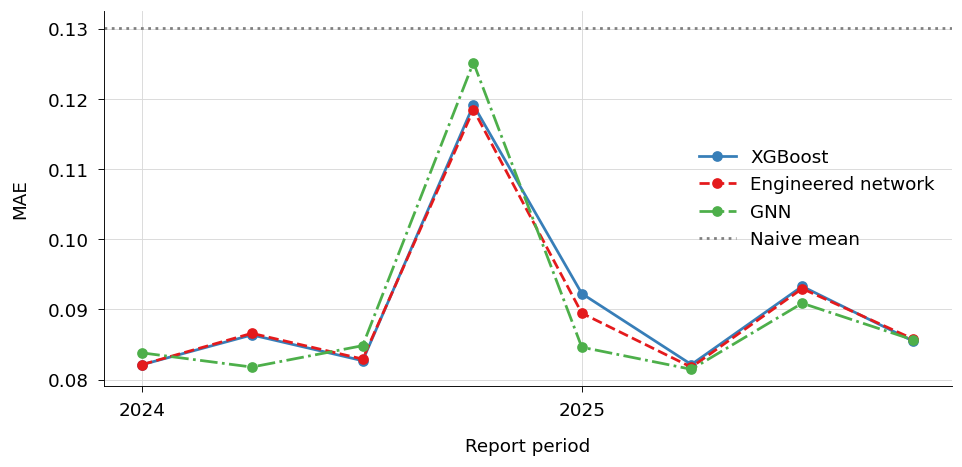

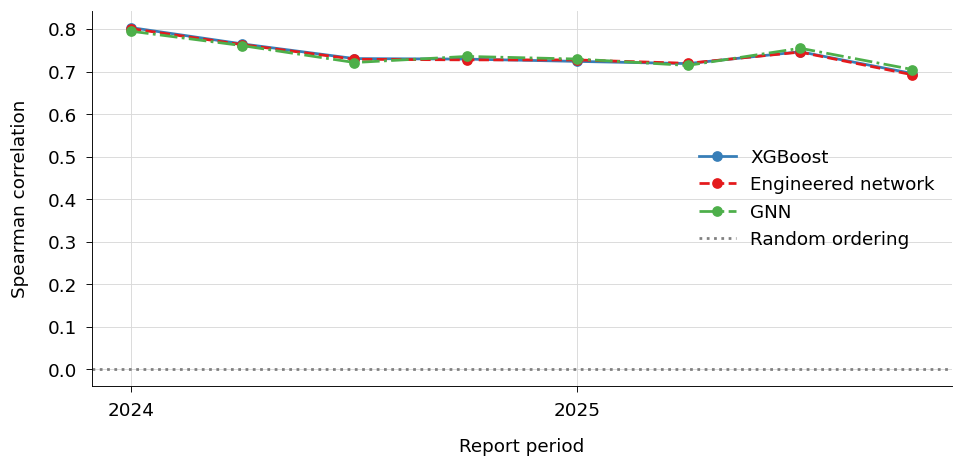

Quarters with lower GNN MAE than XGBoost: 4 / 8
Quarters with higher GNN rank correlation than XGBoost: 4 / 8


In [5]:
line_styles = {
    "XGBoost": {"color": COLOR_PALETTE[0], "linestyle": "-", "marker": "o"},
    "Engineered network": {"color": COLOR_PALETTE[1], "linestyle": "--", "marker": "o"},
    "GNN": {"color": COLOR_PALETTE[2], "linestyle": "-.", "marker": "o"},
}

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

model_names = ["baseline", "engineered_network", "gnn"]

display_names = {
    "baseline": "XGBoost",
    "engineered_network": "Engineered network",
    "gnn": "GNN",
}

quarterly_rows = []

for report_period, quarter in panel.groupby("report_period", sort=True):
    for model in model_names:
        quarterly_rows.append(
            {
                "report_period": report_period,
                "model": display_names[model],
                "mae": mean_absolute_error(
                    quarter["actual"],
                    quarter[f"{model}_prediction"],
                ),
                "spearman": quarter["actual"].corr(
                    quarter[f"{model}_prediction"],
                    method="spearman",
                ),
            }
        )

quarterly_performance = pd.DataFrame(quarterly_rows)

quarter_dates = quarterly_performance["report_period"].drop_duplicates().sort_values()
year_ticks = quarter_dates.groupby(quarter_dates.dt.year).first()

# --------------------------------------------------
# Figure 1: MAE
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4.5))

for model, group in quarterly_performance.groupby("model", sort=False):
    ax.plot(
        group["report_period"],
        group["mae"],
        label=model,
        linewidth=1.8,
        **line_styles[model],
    )

ax.axhline(
    test_benchmark["mae"].item(),
    color="gray",
    linestyle=":",
    linewidth=1.8,
    label="Naive mean",
)

ax.set_ylabel("MAE")
ax.set_xlabel("Report period")

ax.set_xticks(year_ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend(frameon=False)

apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "04_06_held_out_mae_by_quarter.pdf")
plt.show()


# --------------------------------------------------
# Figure 2: Spearman
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4.5))

for model, group in quarterly_performance.groupby("model", sort=False):
    ax.plot(
        group["report_period"],
        group["spearman"],
        label=model,
        linewidth=1.8,
        **line_styles[model],
    )

ax.axhline(
    0,
    color="gray",
    linestyle=":",
    linewidth=1.8,
    label="Random ordering",
)

ax.set_ylabel("Spearman correlation")
ax.set_xlabel("Report period")

ax.set_xticks(year_ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend(frameon=False)

apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "04_06_held_out_spearman_by_quarter.pdf")
plt.show()


wide = quarterly_performance.pivot(
    index="report_period",
    columns="model",
    values=["mae", "spearman"],
)

print(
    f"Quarters with lower GNN MAE than XGBoost: "
    f"{(wide['mae']['GNN'] < wide['mae']['XGBoost']).sum()} / {len(wide)}"
)

print(
    f"Quarters with higher GNN rank correlation than XGBoost: "
    f"{(wide['spearman']['GNN'] > wide['spearman']['XGBoost']).sum()} / {len(wide)}"
)

## 6. Prediction similarity and Fragility Score ordering

Prediction-rank correlations indicate how distinct the signals are. The decile graph then tests whether each score monotonically separates future realized drawdowns.

,XGBoost,Engineered network,GNN
XGBoost,1.0000,0.9958,0.9774
Engineered network,0.9958,1.0000,0.9750
GNN,0.9774,0.9750,1.0000


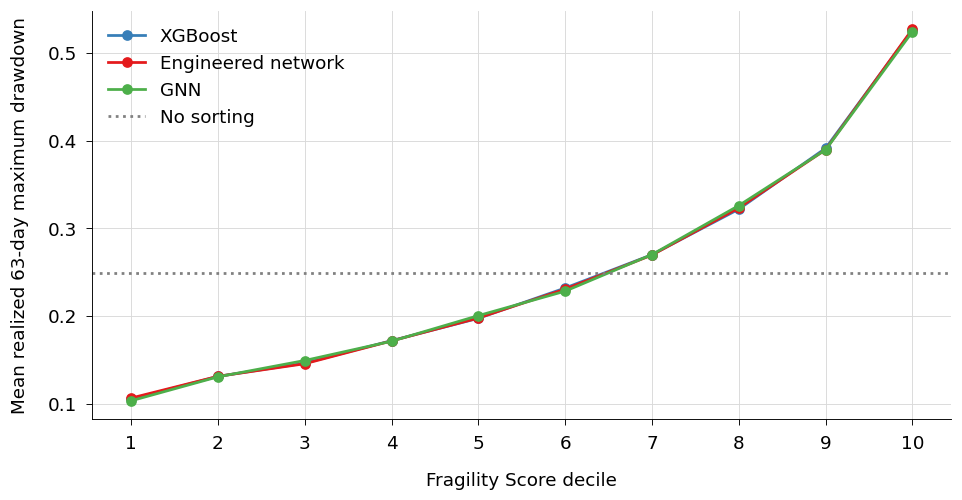

XGBoost: top-minus-bottom spread = 0.4212; increasing steps = 9 / 9
Engineered network: top-minus-bottom spread = 0.4210; increasing steps = 9 / 9
GNN: top-minus-bottom spread = 0.4211; increasing steps = 9 / 9


In [6]:
prediction_columns = [f"{model}_prediction" for model in model_names]
prediction_correlation = panel[prediction_columns].corr(method="spearman")
prediction_correlation.index = [display_names[model] for model in model_names]
prediction_correlation.columns = [display_names[model] for model in model_names]
display(prediction_correlation.style.format("{:.4f}"))

decile_rows = []
for model in model_names:
    score = f"{model}_score"
    decile = np.minimum(np.floor(panel[score] / 10).astype(int) + 1, 10)
    summary = panel.assign(fragility_decile=decile).groupby("fragility_decile", as_index=False).agg(mean_realized_drawdown=("actual", "mean"))
    summary["model"] = display_names[model]
    decile_rows.append(summary)
decile_summary = pd.concat(decile_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
for model, group in decile_summary.groupby("model", sort=False):
    ax.plot(group["fragility_decile"], group["mean_realized_drawdown"], marker="o", label=model)
ax.axhline(panel["actual"].mean(), color="gray", linestyle=":", label="No sorting")
ax.set_xlabel("Fragility Score decile")
ax.set_ylabel("Mean realized 63-day maximum drawdown")
ax.set_xticks(range(1, 11))
ax.legend()
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "04_06_economic_ordering_across_stages.pdf")
plt.show()

for model, group in decile_summary.groupby("model", sort=False):
    values = group.set_index("fragility_decile")["mean_realized_drawdown"]
    print(f"{model}: top-minus-bottom spread = {values.loc[10] - values.loc[1]:.4f}; increasing steps = {(values.diff().dropna() > 0).sum()} / 9")

## 7. Error-pattern comparison

The same descriptive residual diagnostics are calculated for the primary XGBoost and selected GNN. Lower absolute error is better; a positive residual means underprediction. These test diagnostics compare error behavior and do not affect model selection.

,model,mean_residual,predicted_d10_mae,realized_d10_mae,realized_d10_mean_residual,lag_one_residual_correlation
0,XGBoost,+1.08%,16.18%,23.62%,+23.33%,-0.029
1,Temporal GraphSAGE,+2.16%,15.99%,24.16%,+23.90%,0.000


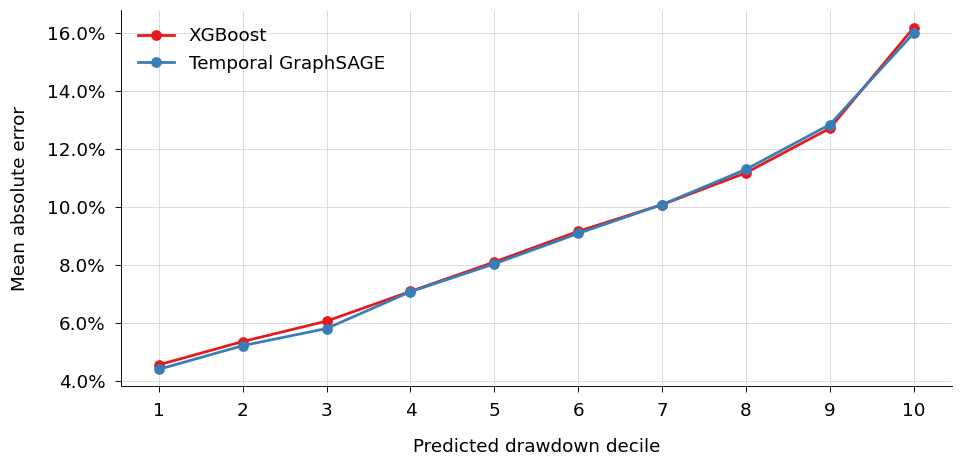

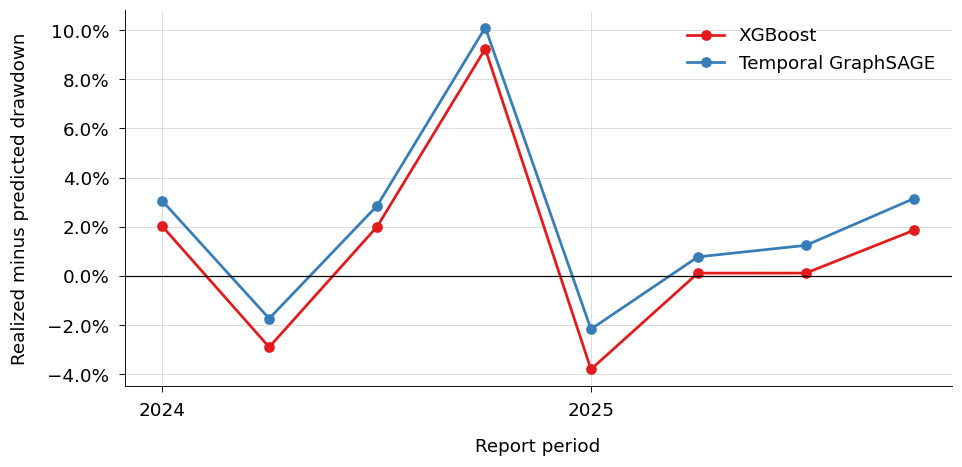

In [7]:
model_predictions = {
    "XGBoost": "baseline_prediction",
    "Temporal GraphSAGE": "gnn_prediction",
}
model_colors = {
    "XGBoost": COLOR_PALETTE[1],
    "Temporal GraphSAGE": COLOR_PALETTE[0],
}
panel["realized_decile"] = pd.qcut(
    panel["actual"].rank(method="first"),
    10,
    labels=False,
) + 1
report_dates = pd.to_datetime(panel["report_period"])
panel["quarter_number"] = report_dates.dt.year * 4 + report_dates.dt.quarter
summary_rows = []
decile_rows = []
quarter_rows = []

for label, prediction_column in model_predictions.items():
    residual = panel["actual"] - panel[prediction_column]
    absolute_error = residual.abs()
    prediction_decile = pd.qcut(
        panel[prediction_column].rank(method="first"),
        10,
        labels=False,
    ) + 1
    severe = panel["realized_decile"].eq(10)
    ordered = panel[["permno", "quarter_number"]].copy()
    ordered["residual"] = residual
    ordered = ordered.sort_values(["permno", "quarter_number"])
    ordered["previous_residual"] = ordered.groupby("permno")["residual"].shift()
    ordered["previous_quarter"] = ordered.groupby("permno")["quarter_number"].shift()
    consecutive = ordered.loc[
        ordered["quarter_number"].eq(ordered["previous_quarter"] + 1)
    ]
    summary_rows.append(
        {
            "model": label,
            "mean_residual": residual.mean(),
            "predicted_d10_mae": absolute_error[prediction_decile.eq(10)].mean(),
            "realized_d10_mae": absolute_error[severe].mean(),
            "realized_d10_mean_residual": residual[severe].mean(),
            "lag_one_residual_correlation": consecutive["residual"].corr(
                consecutive["previous_residual"]
            ),
        }
    )
    for decile in range(1, 11):
        decile_rows.append(
            {
                "model": label,
                "prediction_decile": decile,
                "mae": absolute_error[prediction_decile.eq(decile)].mean(),
            }
        )
    for report_period in sorted(panel["report_period"].unique()):
        quarter = panel["report_period"].eq(report_period)
        quarter_rows.append(
            {
                "model": label,
                "report_period": report_period,
                "mean_residual": residual[quarter].mean(),
            }
        )

error_summary = pd.DataFrame(summary_rows)
error_by_prediction_decile = pd.DataFrame(decile_rows)
quarterly_bias = pd.DataFrame(quarter_rows)
display(
    error_summary.style.format(
        {
            "mean_residual": "{:+.2%}",
            "predicted_d10_mae": "{:.2%}",
            "realized_d10_mae": "{:.2%}",
            "realized_d10_mean_residual": "{:+.2%}",
            "lag_one_residual_correlation": "{:.3f}",
        }
    )
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for index, (label, group) in enumerate(
    error_by_prediction_decile.groupby("model", sort=False)
):
    axis.plot(
        group["prediction_decile"],
        group["mae"],
        marker="o",
        color=model_colors[label],
        label=label,
    )
axis.set_xlabel("Predicted drawdown decile")
axis.set_ylabel("Mean absolute error")
axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_06_error_by_prediction_decile.pdf")
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for index, (label, group) in enumerate(
    quarterly_bias.groupby("model", sort=False)
):
    axis.plot(
        group["report_period"],
        group["mean_residual"],
        marker="o",
        color=model_colors[label],
        label=label,
    )
axis.axhline(0, color="black", linewidth=0.8)
axis.set_xlabel("Report period")
axis.set_ylabel("Realized minus predicted drawdown")
quarter_dates = quarterly_bias["report_period"].drop_duplicates().sort_values()
year_ticks = quarter_dates.groupby(quarter_dates.dt.year).first()
axis.set_xticks(year_ticks)
axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_06_mean_residual_by_test_quarter.pdf")
plt.show()

## 8. Interpretation

The static learning curves show stable convergence. GraphSAGE reaches its selected validation result at epoch 28 and GAT at epoch 26. Their validation MAEs are 0.098452 and 0.099248, respectively, while temporal GraphSAGE performs better within the graph-model family at 0.094499.

The temporal extension is useful within the graph-model family: temporal GraphSAGE has lower validation MAE than both static GraphSAGE and GAT. This supports treating the ownership network as a sequence rather than as unrelated quarterly snapshots. Attention does not improve on weighted GraphSAGE under the fixed specification.

Temporal GraphSAGE does not beat the selected augmented XGBoost model on the validation criterion: its validation MAE is 0.094499 versus 0.094249. On the held-out test sample it has 0.71% lower MAE, but higher RMSE, lower R-squared (0.493 versus 0.504), and only marginally higher mean quarterly rank correlation (0.7394 versus 0.7390). It wins on both MAE and rank correlation in four of eight quarters. This is mixed evidence, not consistent dominance.

All trained models clearly outperform the no-information reference. The historical-mean forecast has test MAE of 0.1302 and negative R-squared of -0.053, while random ordering corresponds to zero expected rank correlation. The narrow differences among trained models should therefore be distinguished from their large common improvement over the benchmark.

Temporal GraphSAGE also improves test MAE over the selected engineered-network model by only 0.25%. All three models produce closely related rankings and strongly ordered Fragility Scores. Because model selection is based on validation MAE rather than test MAE, the augmented XGBoost model remains the primary specification and temporal GraphSAGE is retained as a close graph-learning comparison.

In [8]:
selected_gnn = gnn_validation.loc[gnn_validation["selected"], "model"].iloc[0]
gnn_mae_wins = int((wide["mae"]["GNN"] < wide["mae"]["XGBoost"]).sum())
gnn_rank_wins = int((wide["spearman"]["GNN"] > wide["spearman"]["XGBoost"]).sum())

print(f"Selected GNN: {selected_gnn}")
print(f"GNN validation MAE: {gnn_validation.loc[gnn_validation['selected'], 'mae'].iloc[0]:.6f}")
print(f"GNN test MAE: {gnn_mae:.6f}")
print(f"GNN minus primary XGBoost test MAE: {gnn_mae - baseline_mae:+.6f}")
print(f"GNN MAE wins by quarter: {gnn_mae_wins} / {len(wide)}")
print(f"GNN rank-correlation wins by quarter: {gnn_rank_wins} / {len(wide)}")
print(f"Conclusion: retain {baseline_test.loc[0, 'model']} as the primary Fragility Score model.")
print("GNN model evaluation: PASS")

Selected GNN: temporal_graphsage
GNN validation MAE: 0.094499
GNN test MAE: 0.089762
GNN minus primary XGBoost test MAE: -0.000641
GNN MAE wins by quarter: 4 / 8
GNN rank-correlation wins by quarter: 4 / 8
Conclusion: retain xgboost_augmented as the primary Fragility Score model.
GNN model evaluation: PASS
